# Pendulum Data Preprocessing (Lubricated) - Final Clean Version

Essential workflow for lubricated dataset.

**Key steps:**
1. Load tracking and field data
2. Preprocess (NaN handling, angle unwrapping)
3. Synchronize and interpolate to 2000 Hz
4. Detect drift and apply time-scaling correction

**Output:** `theta_field_trim`, `theta_trk_trim`, `omega_trk_trim`, `alpha_trk_trim`, `mag_field_trim`, `t_trim`

In [1]:
%matplotlib widget

import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Configuration
TRACK_FILE = 'chirp-data/lube3-1.csv'
FIELD_FILE = 'chirp3-lube.csv'
B_START = 214
B_END = 5181
FS_NEW = 2000  # Hz
T_START = 0
T_END = 5
TRIM_END = 5181  # Final length after resampling

## Step 1: Load and Preprocess Tracking Data

In [2]:
# Load tracking data (CSV has 2 header rows)
track_tbl = pd.read_csv(TRACK_FILE, header=1)

t_trk = track_tbl['t'].values
theta_trk = track_tbl['θ'].values / 180 * np.pi  # Convert to radians (already unwrapped)
omega_trk = track_tbl['ω'].values / 180 * np.pi  # Convert to rad/s

# Handle NaN values (backward fill then forward fill)
if np.isnan(omega_trk).sum() > 0:
    omega_series = pd.Series(omega_trk)
    omega_trk = omega_series.bfill().ffill().values

if np.isnan(theta_trk).sum() > 0:
    theta_series = pd.Series(theta_trk)
    theta_trk = theta_series.bfill().ffill().values

print(f"Loaded {len(t_trk)} tracking samples")
print(f"Time range: [{t_trk[0]:.3f}, {t_trk[-1]:.3f}] s")
print(f"Theta range: [{np.min(theta_trk):.2f}, {np.max(theta_trk):.2f}] rad")

Loaded 10070 tracking samples
Time range: [0.000, 5.035] s
Theta range: [-95.44, 121.45] rad


## Step 2: Load and Preprocess Field Data

In [3]:
# Load field data (skip 6 header rows, semicolon-separated)
field_tbl = pd.read_csv(FIELD_FILE, skiprows=6, sep=';')

idx = field_tbl['Index'].values
t_field = idx * 1e-3  # Convert ms to seconds
t_field = t_field[B_START:B_END]  # Trim to relevant window

Bx = field_tbl['Bx[mT]'].values[B_START:B_END]
By = field_tbl['By[mT]'].values[B_START:B_END]
Bz = field_tbl['Bz[mT]'].values[B_START:B_END]

# Compute field angle (wrapped to [-π, π])
theta_field_wrapped = np.arctan2(Bz, By)

# Unwrap field angle to make it continuous (removes discontinuities at ±π)
theta_field = np.unwrap(theta_field_wrapped)

mag_field = np.linalg.norm([By, Bz], axis=0)

print(f"Loaded {len(t_field)} field samples")
print(f"Time range: [{t_field[0]:.3f}, {t_field[-1]:.3f}] s")
print(f"Field angle range: [{np.min(theta_field):.2f}, {np.max(theta_field):.2f}] rad")

Loaded 4967 field samples
Time range: [0.215, 5.181] s
Field angle range: [-95.32, 120.78] rad


## Step 3: Synchronize and Interpolate to 2000 Hz

In [4]:
# Create uniform time grid at 2000 Hz
t_new = np.arange(T_START, T_END + 1/FS_NEW, 1/FS_NEW)

# Offset field time to start at zero
t_field_offset = t_field - t_field[0]

# Interpolate all signals to 2000 Hz using cubic spline
theta_field_spline = interp1d(t_field_offset, theta_field, kind='cubic',
                              bounds_error=False, fill_value='extrapolate')(t_new)
mag_field_spline = interp1d(t_field_offset, mag_field, kind='cubic',
                            bounds_error=False, fill_value='extrapolate')(t_new)
omega_trk_spline = interp1d(t_trk, omega_trk, kind='cubic',
                            bounds_error=False, fill_value='extrapolate')(t_new)
theta_trk_spline = interp1d(t_trk, theta_trk, kind='cubic',
                            bounds_error=False, fill_value='extrapolate')(t_new)

# Compute angular acceleration
alpha_trk_spline = np.gradient(omega_trk_spline, 1/FS_NEW)

# Trim to specified length
theta_field_trim = theta_field_spline[:TRIM_END]
mag_field_trim = mag_field_spline[:TRIM_END]
theta_trk_trim = theta_trk_spline[:TRIM_END]
omega_trk_trim = omega_trk_spline[:TRIM_END]
alpha_trk_trim = alpha_trk_spline[:TRIM_END]
t_trim = t_new[:TRIM_END]

print(f"Resampled to {FS_NEW} Hz")
print(f"Final length: {len(t_trim)} samples ({len(t_trim)/FS_NEW:.3f} seconds)")
print(f"Time range: [0, {t_trim[-1]:.4f}] s")

Resampled to 2000 Hz
Final length: 5181 samples (2.591 seconds)
Time range: [0, 2.5900] s


## Step 4: Detect Drift

In [5]:
# Detect drift: compute phase difference and fit linear trend
phase_diff = theta_field_trim - theta_trk_trim
slope, intercept, r_value, p_value, _ = linregress(t_trim, phase_diff)

print("Drift Analysis:")
print(f"  Slope: {slope:.4f} rad/s ({slope*180/np.pi:.2f} deg/s)")
print(f"  Intercept: {intercept:.4f} rad ({intercept*180/np.pi:.2f}°)")
print(f"  R²: {r_value**2:.4f}")

if abs(slope) > 0.1:
    print(f"  → Significant drift detected: {slope*t_trim[-1]:.3f} rad ({slope*t_trim[-1]*180/np.pi:.1f}°) over {t_trim[-1]:.2f}s")
else:
    print(f"  → No significant drift detected")

Drift Analysis:
  Slope: 0.9915 rad/s (56.81 deg/s)
  Intercept: -1.3910 rad (-79.70°)
  R²: 0.0327
  → Significant drift detected: 2.568 rad (147.1°) over 2.59s


## Step 5: Apply Drift Correction (Time-Scaling)

In [6]:
# Save original data BEFORE correction
theta_field_original_before_correction = theta_field_trim.copy()
mag_field_original_before_correction = mag_field_trim.copy()

# Apply drift correction: time-scaling to fix clock rate mismatch
omega_avg_field = np.mean(np.abs(np.gradient(theta_field_trim, 1/FS_NEW)))
clock_rate_factor = 1 - (slope / omega_avg_field) if omega_avg_field > 0 else 1.0

print(f"\nClock Rate Correction:")
print(f"  Average angular velocity: {omega_avg_field:.2f} rad/s")
print(f"  Clock rate factor: {clock_rate_factor:.6f}")
print(f"  Clock mismatch: {abs(clock_rate_factor - 1.0)*1000:.3f} parts per thousand")

if abs(clock_rate_factor - 1.0) > 0.001:
    # Apply time-scaling: resample field data with corrected time
    # CRITICAL: Both theta_field AND mag_field must be time-scaled together
    # since they come from the same sensor and must remain synchronized
    time_vec_corrected = t_trim * clock_rate_factor
    
    # Interpolate theta_field_trim to corrected time grid
    interp_func_theta = interp1d(t_trim, theta_field_trim, kind='cubic', 
                                  bounds_error=False, fill_value='extrapolate')
    theta_field_corrected = interp_func_theta(time_vec_corrected)
    
    # Interpolate mag_field_trim to corrected time grid (MUST do this too!)
    interp_func_mag = interp1d(t_trim, mag_field_trim, kind='cubic',
                               bounds_error=False, fill_value='extrapolate')
    mag_field_corrected = interp_func_mag(time_vec_corrected)
    
    # Update both with corrected values
    theta_field_trim = theta_field_corrected.copy()
    mag_field_trim = mag_field_corrected.copy()
    
    print(f"\n✓ Drift correction applied (theta_field AND mag_field both time-scaled)")
    print(f"  Time scale: {clock_rate_factor:.6f}x")
    
    # Verify correction
    phase_diff_corrected = theta_field_trim - theta_trk_trim
    slope_corrected, _, _, _, _ = linregress(t_trim, phase_diff_corrected)
    print(f"  Remaining drift: {slope_corrected:.6f} rad/s")
else:
    print("\n→ No correction needed")


Clock Rate Correction:
  Average angular velocity: 241.52 rad/s
  Clock rate factor: 0.995895
  Clock mismatch: 4.105 parts per thousand

✓ Drift correction applied (theta_field AND mag_field both time-scaled)
  Time scale: 0.995895x
  Remaining drift: 0.406926 rad/s


## Step 6: Visualize Before/After Correction

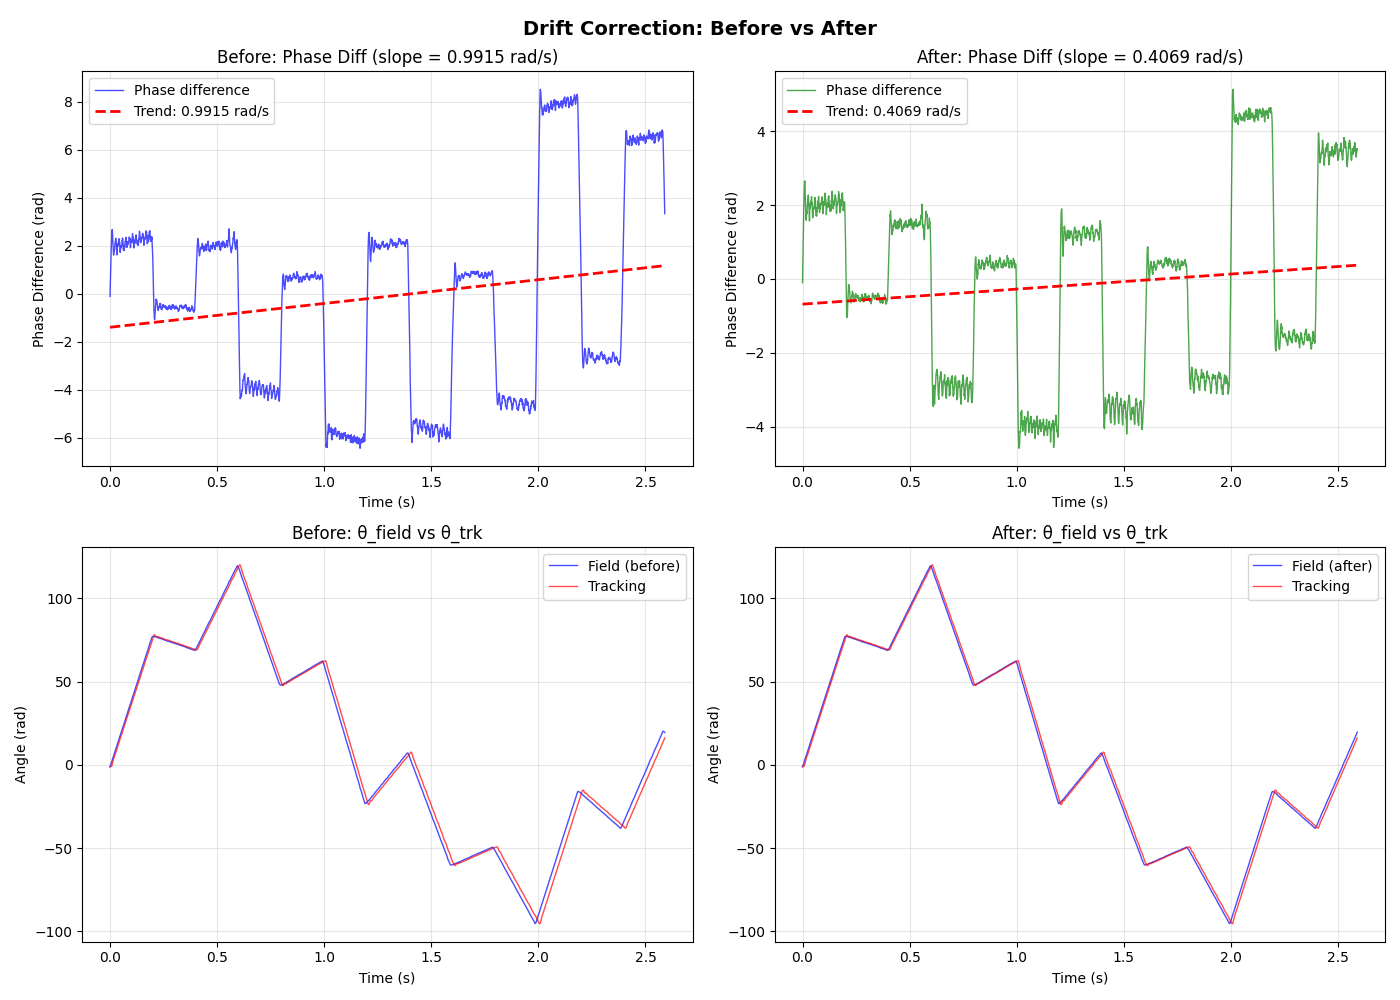


✓ Visualization complete


In [7]:
# Visualization: Before vs After Drift Correction
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Drift Correction: Before vs After', fontsize=14, fontweight='bold')

# Row 1: Phase difference before and after
phase_diff_before = theta_field_original_before_correction - theta_trk_trim
phase_diff_after = theta_field_trim - theta_trk_trim

axes[0, 0].plot(t_trim, phase_diff_before, 'b-', linewidth=1, alpha=0.7, label='Phase difference')
slope_before, intercept_before, _, _, _ = linregress(t_trim, phase_diff_before)
trend_before = slope_before * t_trim + intercept_before
axes[0, 0].plot(t_trim, trend_before, 'r--', linewidth=2, label=f'Trend: {slope_before:.4f} rad/s')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Phase Difference (rad)')
axes[0, 0].set_title(f'Before: Phase Diff (slope = {slope_before:.4f} rad/s)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t_trim, phase_diff_after, 'g-', linewidth=1, alpha=0.7, label='Phase difference')
slope_after, intercept_after, _, _, _ = linregress(t_trim, phase_diff_after)
trend_after = slope_after * t_trim + intercept_after
axes[0, 1].plot(t_trim, trend_after, 'r--', linewidth=2, label=f'Trend: {slope_after:.4f} rad/s')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Phase Difference (rad)')
axes[0, 1].set_title(f'After: Phase Diff (slope = {slope_after:.4f} rad/s)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Row 2: Theta comparison
axes[1, 0].plot(t_trim, theta_field_original_before_correction, 'b-', label='Field (before)', linewidth=1, alpha=0.7)
axes[1, 0].plot(t_trim, theta_trk_trim, 'r-', label='Tracking', linewidth=1, alpha=0.7)
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Angle (rad)')
axes[1, 0].set_title('Before: θ_field vs θ_trk')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t_trim, theta_field_trim, 'b-', label='Field (after)', linewidth=1, alpha=0.7)
axes[1, 1].plot(t_trim, theta_trk_trim, 'r-', label='Tracking', linewidth=1, alpha=0.7)
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Angle (rad)')
axes[1, 1].set_title('After: θ_field vs θ_trk')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization complete")

## Step 7: Friction Estimation (Before vs After Correction)

In [8]:
# Physical parameters for force computation
J_INITIAL = 9.33e-12  # Moment of inertia (kg⋅m²)
B_MAGNET_INITIAL = 0.00113  # Magnetic moment (A⋅m²)

# Compute friction BEFORE correction (using original, uncorrected data)
B_ext_before = mag_field_original_before_correction * 1e-3  # Convert mT to T
B_const_before = B_MAGNET_INITIAL * B_ext_before
torque_before = B_const_before * np.sin(theta_field_original_before_correction - theta_trk_trim)
frc_before = torque_before - J_INITIAL * alpha_trk_trim

# Compute friction AFTER correction (using time-scaled theta_field AND mag_field)
B_ext_after = mag_field_trim * 1e-3  # Convert mT to T (now using corrected mag_field!)
B_const_after = B_MAGNET_INITIAL * B_ext_after
torque_after = B_const_after * np.sin(theta_field_trim - theta_trk_trim)
frc_after = torque_after - J_INITIAL * alpha_trk_trim

print("="*70)
print("FRICTION COMPARISON: Before vs After Time-Scaling Correction")
print("="*70)

print(f"\nFriction Statistics:")
print(f"  BEFORE correction:")
print(f"    Range: [{np.min(frc_before):.6e}, {np.max(frc_before):.6e}] N⋅m")
print(f"    Std:   {np.std(frc_before):.6e} N⋅m")
print(f"    Mean:  {np.mean(frc_before):.6e} N⋅m")
print(f"\n  AFTER correction:")
print(f"    Range: [{np.min(frc_after):.6e}, {np.max(frc_after):.6e}] N⋅m")
print(f"    Std:   {np.std(frc_after):.6e} N⋅m")
print(f"    Mean:  {np.mean(frc_after):.6e} N⋅m")
print(f"\n  Difference:")
print(f"    Std change: {np.std(frc_after) - np.std(frc_before):.6e} N⋅m")
print(f"    Mean change: {np.mean(frc_after) - np.mean(frc_before):.6e} N⋅m")

# 3D Visualization: Compare friction before and after
import plotly.graph_objects as go

omega_offset = omega_trk_trim - np.min(omega_trk_trim)
theta_wrapped_viz = theta_trk_trim % (2 * np.pi)

x_coords = omega_offset * np.cos(theta_wrapped_viz)
y_coords = omega_offset * np.sin(theta_wrapped_viz)

camera = dict(eye=dict(x=1.5, y=1.5, z=1.2))

# Plot 1: Friction BEFORE correction
fig_before = go.Figure(data=[go.Scatter3d(
    x=x_coords,
    y=y_coords,
    z=frc_before,
    mode='markers',
    marker=dict(
        size=2,
        color=frc_before,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Friction (N⋅m)", x=1.15, len=0.7, thickness=15),
        opacity=0.6
    ),
    text=[f"θ={theta_wrapped_viz[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc_before[i]:.2e} N⋅m" 
          for i in range(len(frc_before))],
    hovertemplate='%{text}<extra></extra>'
)])

fig_before.update_layout(
    title=f'Friction BEFORE Time-Scaling Correction<br>std={np.std(frc_before):.6e} N⋅m',
    scene=dict(
        xaxis_title='ω·cos(θ) (rad/s)',
        yaxis_title='ω·sin(θ) (rad/s)',
        zaxis_title='Friction (N⋅m)',
        aspectmode='cube'
    ),
    width=700,
    height=600,
    margin=dict(r=100),
    scene_camera=camera
)

# Plot 2: Friction AFTER correction
fig_after = go.Figure(data=[go.Scatter3d(
    x=x_coords,
    y=y_coords,
    z=frc_after,
    mode='markers',
    marker=dict(
        size=2,
        color=frc_after,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Friction (N⋅m)", x=1.15, len=0.7, thickness=15),
        opacity=0.6
    ),
    text=[f"θ={theta_wrapped_viz[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc_after[i]:.2e} N⋅m" 
          for i in range(len(frc_after))],
    hovertemplate='%{text}<extra></extra>'
)])

fig_after.update_layout(
    title=f'Friction AFTER Time-Scaling Correction<br>std={np.std(frc_after):.6e} N⋅m',
    scene=dict(
        xaxis_title='ω·cos(θ) (rad/s)',
        yaxis_title='ω·sin(θ) (rad/s)',
        zaxis_title='Friction (N⋅m)',
        aspectmode='cube'
    ),
    width=700,
    height=600,
    margin=dict(r=100),
    scene_camera=camera
)

print("\nShowing 3D friction visualizations:")
print("  1. BEFORE time-scaling correction")
print("  2. AFTER time-scaling correction")

fig_before.show()
fig_after.show()

print(f"\n✓ Friction comparison complete")


FRICTION COMPARISON: Before vs After Time-Scaling Correction

Friction Statistics:
  BEFORE correction:
    Range: [-3.526843e-06, 4.326339e-06] N⋅m
    Std:   1.509235e-06 N⋅m
    Mean:  1.256605e-06 N⋅m

  AFTER correction:
    Range: [-4.155024e-06, 3.798569e-06] N⋅m
    Std:   1.888370e-06 N⋅m
    Mean:  2.602927e-07 N⋅m

  Difference:
    Std change: 3.791350e-07 N⋅m
    Mean change: -9.963127e-07 N⋅m

Showing 3D friction visualizations:
  1. BEFORE time-scaling correction
  2. AFTER time-scaling correction



✓ Friction comparison complete
